\8/*]]474|
# 📄 Titanic

 
 1. Introduction
The dataset used in this study is based on the historical event RMS Titanic disaster, which occurred in 1912 when a British passenger ship sank after colliding with an iceberg. This tragic incident led to the loss of more than 1,500 lives and is one of the most studied maritime disasters in history.

The Titanic dataset is widely used in data science and machine learning to analyze survival patterns and understand the factors that influenced passenger outcomes. The dataset contains information about passengers such as their age, gender, ticket class, fare, and family relationships.

The primary objective of this dataset is to:

Analyze survival patterns

Identify key factors affecting survival

Build predictive models


📊 2. Dataset Overview

Total Rows: 891

Total Columns: 12

🔹 Features:
PassengerId

Survived (Target Variable)

Pclass

Name

Sex

Age

SibSp

Parch

Ticket

Fare

Cabin

Embarked


 3. Objective of Analysis
 4. 
The main goals of this analysis are:

To understand which factors influenced survival

To perform exploratory data analysis (EDA)

To identify patterns and relationships in the dataset

To prepare the data for machine learning


📈 4. Key Insights

🔹 Gender Impact
Females had significantly higher survival rates than males

🔹 Passenger Class
1st class passengers had the highest survival

3rd class passengers had the lowest survival

🔹 Age Factor
Children had higher survival

Elderly had lower survival

🔹 Fare
Higher fare → higher survival probability

🔹 Family Size
Medium family size → better survival

Alone or large families → lower survival


5. Data Issues
   
 Missing Values
Age has missing values

Cabin has a large number of missing values

Embarked has a few missing entries

 Irrelevant Features
Name, Ticket, PassengerId are not useful for prediction

 Data Imbalance
More passengers died than survived



 6. Feature Engineering (Possible)
 7. 
Create Family Size = SibSp + Parch + 1

Extract titles from Name (Mr, Mrs, etc.)

Convert categorical data into numerical format



 7. Machine Learning Scope
This dataset is suitable for:

Classification problems

Predicting survival probability

Models that can be applied:
Logistic Regression

Decision Tree

Random Forest



🌍 8. Real-World Applications
Disaster management planning

Risk assessment

Social behavior analysis

Decision-making under crisis



 9. Conclusion
The analysis of the Titanic dataset shows that survival was influenced by multiple factors such as gender, passenger class, age, and economic status. The findings highlight social inequality and priority-based rescue strategies followed during the disaster.

This dataset serves as a valuable resource for learning data analysis, understanding real-world patterns, and building predictive models.




In [3]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


🔍 1. Data Understanding (Basic Info)

Rows: 891 passengers
Columns: 12 features

Important Columns:
Survived → Target (0 = died, 1 = survived)

Pclass → Ticket class (1 = rich, 3 = poor)

Sex → Male/Female

Age → Age of passenger

Fare → Ticket price

SibSp → Siblings/spouse

Parch → Parents/children

Embarked → Port (S, C, Q)



📊 2. Key Findings (Insights)


 1. Gender impact (VERY STRONG)
Females survival rate >> Males

 Insight: “Women first” rule followed


2. Class matters
Pclass 1 (rich) → highest survival

Pclass 3 (poor) → lowest survival

 Insight: Rich people had better access to lifeboats

 3. Fare (money effect)
Higher fare → higher survival
 Direct relation between wealth & survival

 4. Age pattern
Children had better survival

Elderly lower survival

 Priority given to kids

 5. Family effect
Small families (1–3 members) → higher survival

Alone or large families → lower survival

Balance is important (support vs crowd)

 3. Mistakes / Data Problems
 1. Missing Values
Age → missing

Cabin → mostly missing (almost useless)

Embarked → few missing


 2. Irrelevant Columns
Name

Ticket

PassengerId

 These don’t help prediction directly

3. Categorical Encoding Needed
Sex, Embarked are text
ML needs numbers → encode required

 4. Outliers
Fare has extreme values
 Can distort analysis



In [ ]:
📊 6. Simple Summary (Remember This)
Survival depends mainly on:

Gender (female ↑)

Class (rich ↑)

Fare (high ↑)

Family size (medium ↑)


In [ ]:
Column  	    Meaning   	        Type
PassengerId    Unique ID	        Numerical
Survived	   Target (0/1)	        Categorical
Pclass	       Ticket class	        Ordinal
Name	       Passenger name	    Text
Sex	           Gender	            Categorical
Age	           Age	                Numerical
SibSp	       Siblings/spouse	    Numerical
Parch	       Parents/children	    Numerical
Ticket	       Ticket number	    Text
Fare	       Ticket price	        Numerical
Cabin	       Cabin number	        Text
Embarked	   Port (S,C,Q)	        Categorical

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,7.140000e+02,891.000000,891.000000,8.910000e+02
mean,446.000000,0.383838,2.308642,2.388379e-16,0.523008,0.381594,-1.938841e-16
std,257.353842,0.486592,0.836071,1.000701e+00,1.102743,0.806057,1.000562e+00
min,1.000000,0.000000,1.000000,-2.016979e+00,0.000000,0.000000,-3.058578e+00
25%,223.500000,0.000000,2.000000,-6.595416e-01,0.000000,0.000000,-8.002318e-01
50%,446.000000,0.000000,3.000000,-1.170488e-01,0.000000,0.000000,-2.316613e-01
75%,668.500000,1.000000,3.000000,5.718310e-01,1.000000,0.000000,5.198636e-01
max,891.000000,1.000000,3.000000,3.465126e+00,8.000000,6.000000,3.385294e+00


In [32]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [33]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [34]:
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [35]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [36]:
import pandas as pd
import numpy as np

# -------------------------------
# STEP 0: Column names clean
# -------------------------------
df.columns = df.columns.str.strip()

# -------------------------------  
# STEP 1: Missing Values Fix
# -------------------------------

# Age → median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked → mode (safe way)
if df['Embarked'].mode().empty:
    df['Embarked'] = df['Embarked'].fillna('S')
else:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode().iloc[0])

# Cabin → drop (too many missing)
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)

# -------------------------------
# STEP 2: Feature Engineering
# -------------------------------

# Family Size
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Is Alone
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# Title extract (only if Name exists)
if 'Name' in df.columns:
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df = df.drop('Name', axis=1)

# Age Group
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[0,12,18,35,60,100],
                        labels=['Child','Teen','Young','Adult','Senior'])

# Fare Group
df['Fare_Group'] = pd.qcut(df['Fare'], 4,
                          labels=['Low','Medium','High','Very High'])

# -------------------------------
# STEP 3: Remove unnecessary columns
# -------------------------------

cols_to_drop = ['PassengerId', 'Ticket']
for col in cols_to_drop:
    if col in df.columns:
        df = df.drop(col, axis=1)

# -------------------------------
# STEP 4: Encoding (Categorical → Numeric)
# -------------------------------

# Sex encoding
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# One-hot encoding
categorical_cols = ['Embarked', 'Title', 'Age_Group', 'Fare_Group']

for col in categorical_cols:
    if col in df.columns:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

# -------------------------------
# STEP 5: Final Check
# -------------------------------

print("Missing Values:\n", df.isnull().sum())
print("\nData Info:\n")
print(df.info())

print("\nPreview:\n")
print(df.head())

Missing Values:
 Survived                0
Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Family_Size             0
Is_Alone                0
Embarked_Q              0
Embarked_S              0
Title_Col               0
Title_Countess          0
Title_Don               0
Title_Dr                0
Title_Jonkheer          0
Title_Lady              0
Title_Major             0
Title_Master            0
Title_Miss              0
Title_Mlle              0
Title_Mme               0
Title_Mr                0
Title_Mrs               0
Title_Ms                0
Title_Rev               0
Title_Sir               0
Age_Group_Teen          0
Age_Group_Young         0
Age_Group_Adult         0
Age_Group_Senior        0
Fare_Group_Medium       0
Fare_Group_High         0
Fare_Group_Very High    0
dtype: int64

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
D

In [38]:
df['Fare'] = np.log1p(df['Fare'])

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [40]:
df.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family_Size,Is_Alone,Embarked_Q,...,Title_Ms,Title_Rev,Title_Sir,Age_Group_Teen,Age_Group_Young,Age_Group_Adult,Age_Group_Senior,Fare_Group_Medium,Fare_Group_High,Fare_Group_Very High
Survived,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.152404,0.016639,-0.203367,0.003650,...,0.042470,-0.064988,0.042470,NaN,NaN,NaN,NaN,-0.095648,0.084239,0.233638
Pclass,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.408856,0.065997,0.135207,0.221009,...,-0.012381,-0.030413,-0.052496,NaN,NaN,NaN,NaN,0.213210,-0.057507,-0.579206
Sex,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.092366,0.200988,-0.303646,0.074115,...,0.045439,-0.060741,-0.024728,NaN,NaN,NaN,NaN,-0.064664,0.080195,0.177966
Age,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.067819,-0.245619,0.171647,-0.031415,...,-0.003507,0.087355,0.050589,NaN,NaN,NaN,NaN,-0.021288,-0.021924,0.094452
SibSp,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.206516,0.890712,-0.584471,-0.026354,...,-0.015907,-0.026622,0.014507,NaN,NaN,NaN,NaN,-0.197540,0.119821,0.324653
Parch,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.201037,0.783111,-0.583398,-0.081228,...,-0.015878,-0.021967,-0.015878,NaN,NaN,NaN,NaN,-0.203848,0.165192,0.297252
Fare,0.152404,-0.408856,0.092366,0.067819,0.206516,0.201037,1.000000,0.247229,-0.315417,0.002269,...,-0.023139,-0.030991,0.024387,NaN,NaN,NaN,NaN,-0.696159,0.102276,0.491622
Family_Size,0.016639,0.065997,0.200988,-0.245619,0.890712,0.783111,0.247229,1.000000,-0.690922,-0.058592,...,-0.018804,-0.029170,0.001983,NaN,NaN,NaN,NaN,-0.236851,0.164420,0.370392
Is_Alone,-0.203367,0.135207,-0.303646,0.171647,-0.584471,-0.583398,-0.315417,-0.690922,1.000000,0.086464,...,0.027216,0.010764,-0.041285,NaN,NaN,NaN,NaN,0.274902,-0.306487,-0.370120
Embarked_Q,0.003650,0.221009,0.074115,-0.031415,-0.026354,-0.081228,0.002269,-0.058592,0.086464,1.000000,...,-0.010310,0.023515,-0.010310,NaN,NaN,NaN,NaN,-0.122992,-0.010945,-0.158703


In [41]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Survived              891 non-null    int64  
 1   Pclass                891 non-null    int64  
 2   Sex                   891 non-null    int64  
 3   Age                   891 non-null    float64
 4   SibSp                 891 non-null    int64  
 5   Parch                 891 non-null    int64  
 6   Fare                  571 non-null    float64
 7   Family_Size           891 non-null    int64  
 8   Is_Alone              891 non-null    int64  
 9   Embarked_Q            891 non-null    bool   
 10  Embarked_S            891 non-null    bool   
 11  Title_Col             891 non-null    bool   
 12  Title_Countess        891 non-null    bool   
 13  Title_Don             891 non-null    bool   
 14  Title_Dr              891 non-null    bool   
 15  Title_Jonkheer        8

In [42]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family_Size,Is_Alone
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,5.710000e+02,891.000000,891.000000
mean,0.383838,2.308642,0.352413,-1.594933e-17,0.523008,0.381594,3.110958e-18,1.904602,0.602694
std,0.486592,0.836071,0.477990,1.000562e+00,1.102743,0.806057,1.000877e+00,1.613459,0.489615
min,0.000000,1.000000,0.000000,-2.224156e+00,0.000000,0.000000,-5.849023e+00,1.000000,0.000000
25%,0.000000,2.000000,0.000000,-5.657365e-01,0.000000,0.000000,-2.390837e-01,1.000000,0.000000
50%,0.000000,3.000000,0.000000,-1.046374e-01,0.000000,0.000000,2.701769e-01,1.000000,1.000000
75%,1.000000,3.000000,1.000000,4.333115e-01,1.000000,0.000000,5.620023e-01,2.000000,1.000000
max,1.000000,3.000000,1.000000,3.891554e+00,8.000000,6.000000,9.418146e-01,11.000000,1.000000


# univaraite analysis

In [ ]:
1. Survival rate बहुत low थी
केवल लगभग 38% passengers survive हुए।
Majority passengers की death हुई।

2. Most passengers 3rd class में थे
Dataset में third class passengers सबसे ज्यादा हैं।
Lower economic class dominate कर रही थी।

3. Male passengers ज्यादा थे
लगभग 65% passengers male थे।
Female passengers comparatively कम थीं।

4. Age mostly young adults की थी
Majority passengers young या adult category में थे।
बहुत कम senior citizens थे।

5. Fare distribution highly skewed थी
अधिकांश passengers ने low fare pay किया।
कुछ passengers ने बहुत high fare दिया।

6. Most people traveled alone
लगभग 60% passengers अकेले travel कर रहे थे।

7. Family size generally small था
Most passengers 1–3 family members के साथ थे।

8. Very large families rare थीं
Few passengers ही 8–11 family members के साथ travel कर रहे थे।

9. Scaled Age and Fare properly normalized हैं
Mean लगभग 0 है।
Standard deviation लगभग 1 है।

10. Fare_Per_Person feature wealth indicate करता है
कुछ passengers luxury-level spending कर रहे थे।
Economic inequality clearly दिखाई देती है।




10 Important Univariate Patterns
1.

Titanic में death rate survival से ज्यादा थी।

2.

Third class overcrowded थी।

3.

Male passengers dominate कर रहे थे।

4.

Young adults ship population का major हिस्सा थे।

5.

Rich passengers बहुत कम थे।

6.

Most fares low-price category में थे।

7.

Solo travelers ज्यादा थे।

8.

Large family groups uncommon थे।

9.

Economic status highly uneven था।

10.

Dataset balanced नहीं है क्योंकि survival minority class है।

In [6]:
import pandas as pd
import numpy as np

# ==============================
# VISUALIZATION LIBRARIES
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns


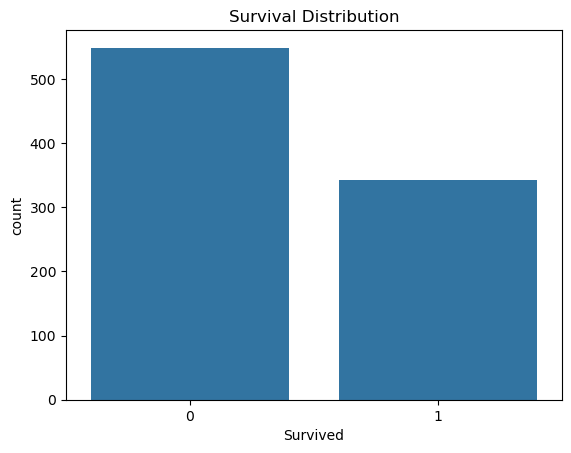

In [7]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

In [ ]:
Non-survivors significantly ज्यादा हैं।
Titanic disaster में majority passengers बच नहीं पाए।
Dataset imbalanced है।

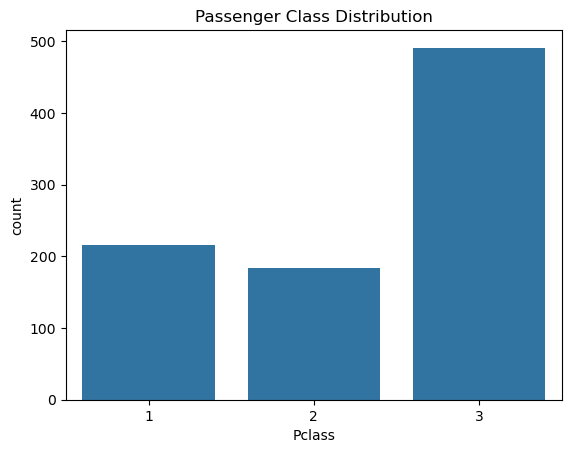

In [8]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

In [ ]:
Third class passengers सबसे ज्यादा थे।
Wealth inequality clearly visible है।
Upper-class passengers comparatively कम थे।

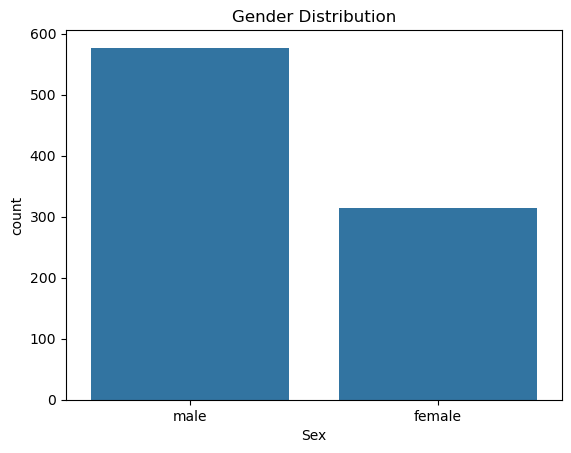

In [9]:
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

In [ ]:
Male passengers clearly dominate कर रहे हैं।
Female passenger proportion काफी कम थी।
Gender imbalance dataset में strong है।

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Survived              891 non-null    int64  
 1   Pclass                891 non-null    int64  
 2   Sex                   891 non-null    int64  
 3   Age                   891 non-null    float64
 4   SibSp                 891 non-null    int64  
 5   Parch                 891 non-null    int64  
 6   Fare                  571 non-null    float64
 7   Family_Size           891 non-null    int64  
 8   Is_Alone              891 non-null    int64  
 9   Embarked_Q            891 non-null    bool   
 10  Embarked_S            891 non-null    bool   
 11  Title_Col             891 non-null    bool   
 12  Title_Countess        891 non-null    bool   
 13  Title_Don             891 non-null    bool   
 14  Title_Dr              891 non-null    bool   
 15  Title_Jonkheer        8

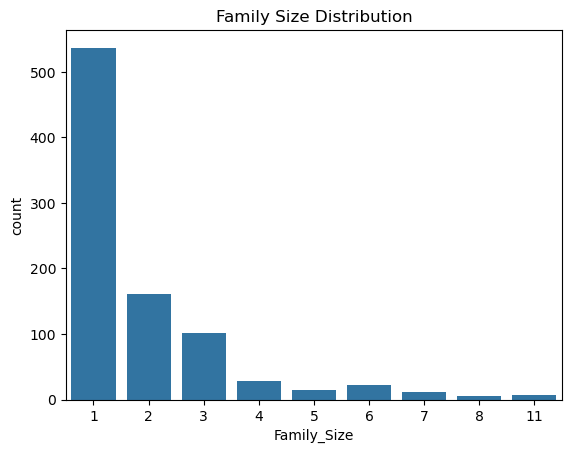

In [43]:
sns.countplot(x='Family_Size', data=df)
plt.title('Family Size Distribution')
plt.show()

In [ ]:
Solo travelers सबसे ज्यादा हैं।
Small family groups common हैं।
Large families बहुत rare हैं।

In [61]:
def get_fare_group(row):

    if row['Fare_Group_Very High'] == 1:
        return 'Very High'

    elif row['Fare_Group_High'] == 1:
        return 'High'

    elif row['Fare_Group_Medium'] == 1:
        return 'Medium'

    else:
        return 'Low'

df['Fare_Group_Label'] = df.apply(get_fare_group, axis=1)

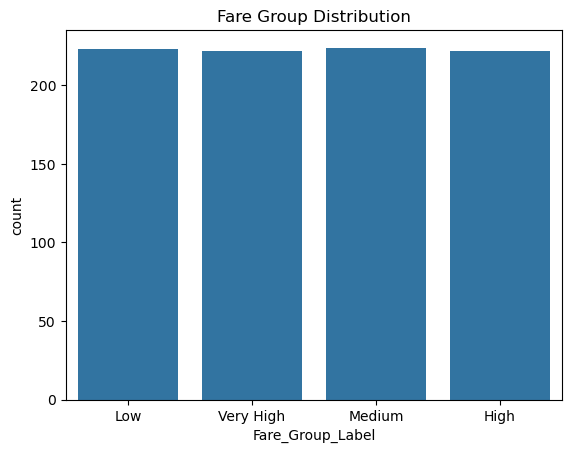

In [62]:
sns.countplot(x='Fare_Group_Label', data=df)

plt.title('Fare Group Distribution')

plt.show()

In [ ]:
Majority passengers low-fare category में थे।
Luxury travelers बहुत कम थे।
Titanic economically highly unequal थी।

In [ ]:
Strongest Findings

Titanic mainly lower-class passengers से भरी थी।
Male passengers majority में थे।
Most passengers survive नहीं हुए।
Wealth distribution highly unequal थी।
Solo travel common था।
Small families dominate कर रही थीं।
Rich passengers dataset का छोटा हिस्सा थे।
Fare और class economic status strongly indicate करते हैं।

# bivariate analysis

In [ ]:
1. Females had much higher survival rates
Female passengers survived significantly more than males.
Gender strongly influenced rescue priority.
    
2. First-class passengers survived more
Passengers in 1st class had the highest survival probability.
Wealthier passengers received better access to safety.

3. Third-class passengers had the lowest survival
Most deaths occurred in 3rd class.
Lower economic class faced greater risk.

4. Children survived more than adults
Young passengers received rescue priority.
Survival decreased with increasing age.

5. High-fare passengers survived more
Expensive ticket holders had better survival chances.
Fare reflected economic and social status.

6. Small families survived better
Families with 2–4 members showed better survival.
Extremely large families struggled during evacuation.

7. Solo travelers had lower survival
Passengers traveling alone died more frequently.
Group support may have improved rescue chances.

8. Female passengers in all classes survived better
Gender effect remained strong across every class category.

9. Mr title had the lowest survival
Adult male passengers faced the highest mortality.
Mrs and Miss titles had much higher survival.
    
10. Fare_Per_Person positively affected survival
Passengers spending more per person survived more often.
Wealth strongly influenced outcomes.



    
10 Important Bivariate Patterns
1.

Sex was the strongest survival predictor.

2.

Women and children received rescue priority.

3.

First-class passengers were safer than lower classes.

4.

Third-class males had the worst survival rates.

5.

Higher fare correlated with higher survival.

6.

Small family groups performed better than large ones.

7.

Traveling alone reduced survival probability.

8.

Economic status strongly influenced rescue outcomes.

9.

Titles captured hidden social hierarchy.

10.

Class and gender together created the strongest survival pattern.

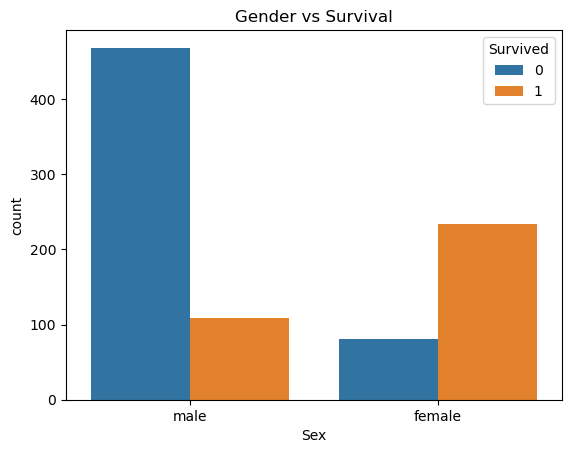

In [14]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Gender vs Survival')
plt.show()

In [ ]:
Female survival was dramatically higher.
Male passengers experienced the highest death count.
Gender was the strongest survival factor.

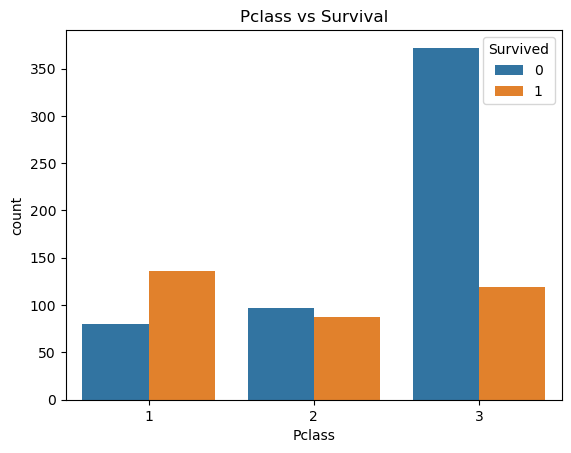

In [15]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Pclass vs Survival')
plt.show()

In [ ]:
First-class passengers survived the most.
Third-class passengers suffered the highest deaths.
Economic class strongly affected rescue chances.

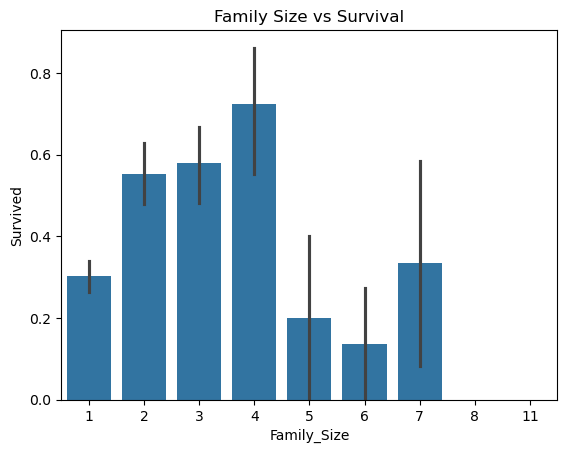

In [53]:
sns.barplot(x='Family_Size', y='Survived', data=df)
plt.title('Family Size vs Survival')
plt.show()

In [ ]:
Small families had the best survival chances.
Extremely large families struggled during evacuation.
Traveling completely alone also reduced survival.

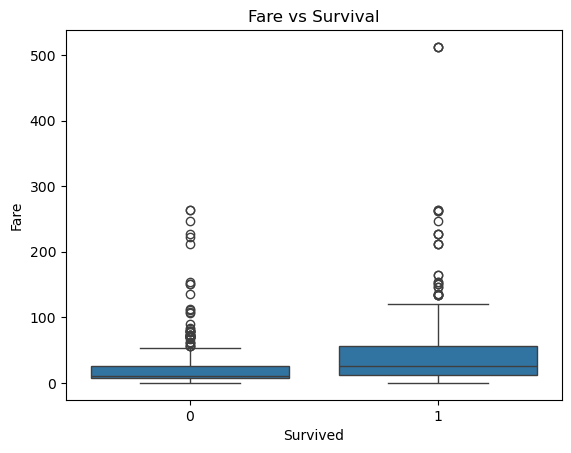

In [17]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')
plt.show()

In [ ]:
Survivors paid significantly higher fares.
Wealthier passengers had greater survival probability.
Fare acted as a strong economic indicator.

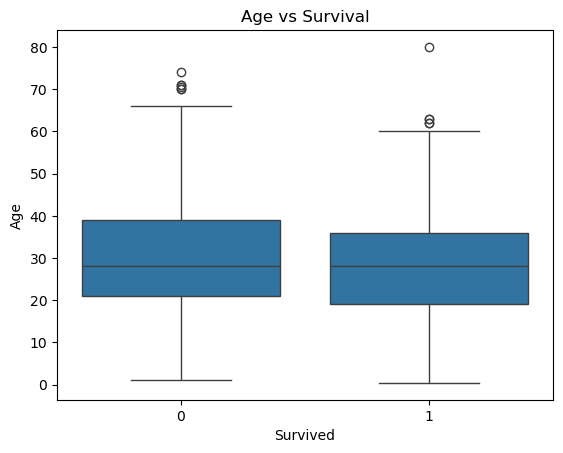

In [18]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age vs Survival')
plt.show()

In [ ]:
Children had the highest survival rates.
Survival probability decreased with age.
Senior passengers faced the greatest risk.

In [ ]:
Strongest Findings

Gender was the most powerful survival factor.
First-class passengers had major advantages.
Wealth strongly improved survival probability.
Children received rescue priority.
Third-class adult males suffered the highest mortality.
Small family groups performed better.
Solo travelers struggled more during evacuation.
Fare and class reflected economic privilege.

# multivariate analysis

In [ ]:
1. Female passengers in first class had the highest survival
Wealthy women were the safest group on the Titanic.
Gender and class together created extremely high survival rates.

2. Third-class adult males had the lowest survival
Poor adult men suffered the highest mortality.
This was the most vulnerable passenger group.
    
3. High fare + female passengers survived the most
Wealth and gender together strongly increased survival chances.
    
4. Children in upper classes survived more frequently
Rescue priority was stronger for wealthy children.

5. Small families in first and second class survived better
Medium-sized family groups had balanced evacuation support.

6. Large families in third class had poor survival
Overcrowding and lower economic status reduced rescue chances.

7. Female passengers survived well across almost all classes
Gender advantage remained consistent regardless of class.

8. Alone passengers in third class had very low survival
Lack of family support and poor class conditions increased deaths.

9. Fare_Per_Person combined with class strongly reflected survival
Passengers spending more individually had better rescue outcomes.

10. Sex + Pclass + Fare became the strongest predictive combination
These three variables together explained most survival patterns.


    
10 Important Multivariate Patterns
1.

Gender and class together dominated survival outcomes.

2.

First-class women formed the safest passenger category.

3.

Third-class men formed the highest-risk category.

4.

Economic status heavily influenced evacuation success.

5.

Children received stronger rescue priority in higher classes.

6.

Large low-income families struggled most during evacuation.

7.

Wealth increased survival probability across genders.

8.

Female survival advantage remained strong in every class.

9.

Fare and passenger class reflected hidden social hierarchy.

10.

Combined engineered features improved survival prediction significantly.

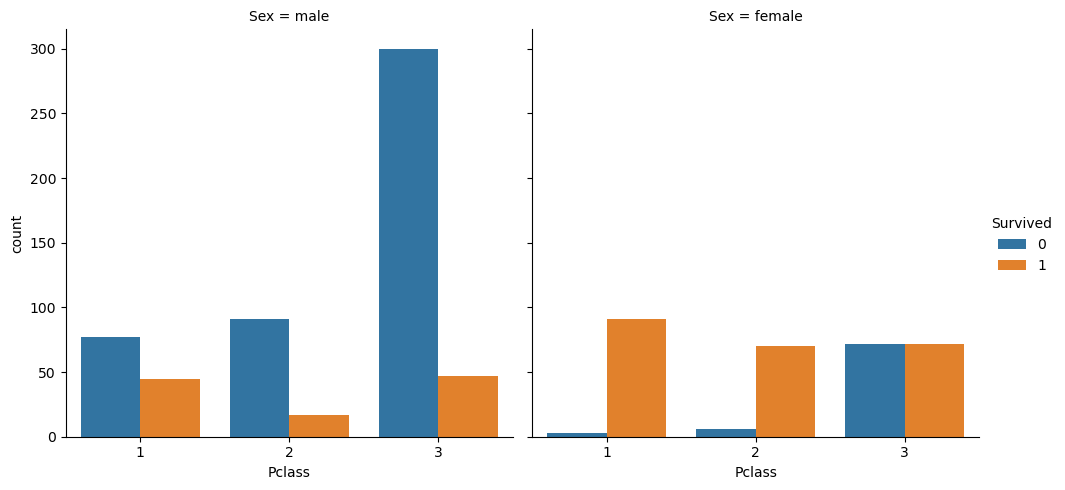

In [19]:
sns.catplot(x='Pclass', hue='Survived',
            col='Sex', data=df, kind='count')
plt.show()

In [ ]:
First-class women had extremely high survival.
Third-class men had the worst survival outcomes.
Gender and class together created the strongest survival pattern.

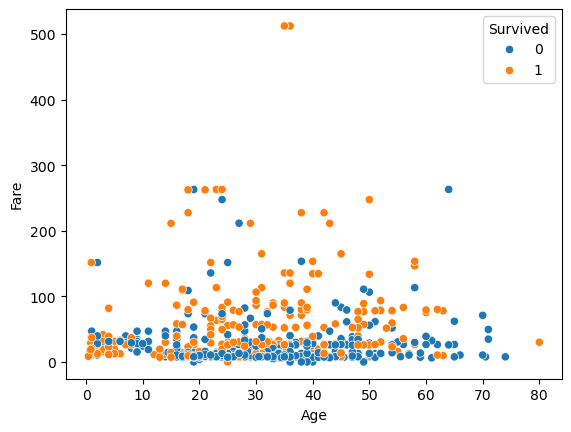

In [20]:
sns.scatterplot(x='Age', y='Fare',
                hue='Survived', data=df)

plt.show()

In [ ]:
Higher fare passengers survived more frequently.
Young passengers with expensive tickets showed stronger survival.
Older low-fare passengers faced greater risk.

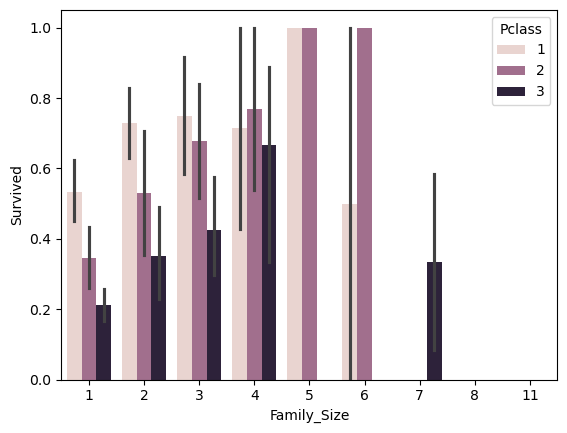

In [55]:
sns.barplot(x='Family_Size',
            y='Survived',
            hue='Pclass',
            data=df)
plt.show()

In [ ]:
Small families performed better than large families.
Third-class large families had extremely poor survival.
Economic status amplified family survival differences.

<Axes: xlabel='Fare_Group_Label', ylabel='count'>

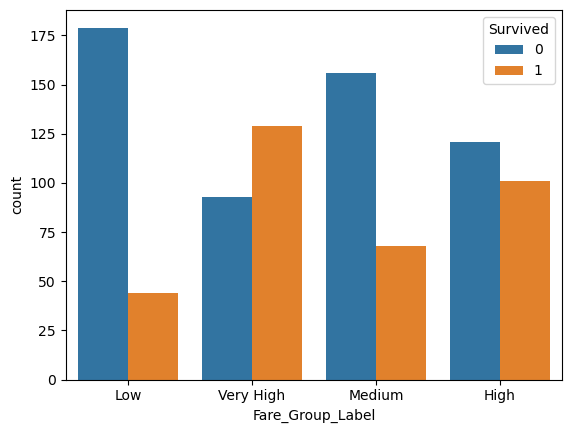

In [66]:
sns.countplot(x='Fare_Group_Label',
              hue='Survived',
              data=df)

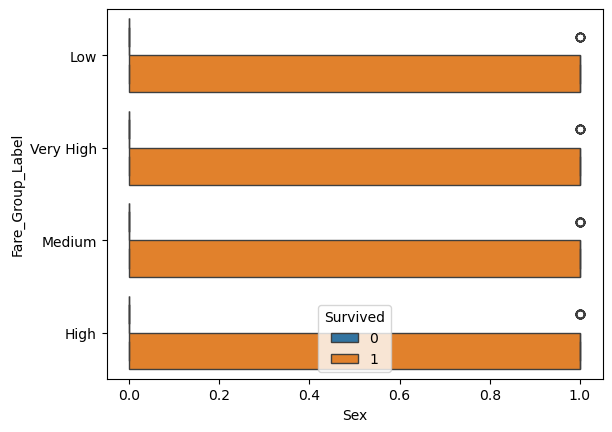

In [68]:
sns.boxplot(x='Sex',
            y='Fare_Group_Label',
            hue='Survived',
            data=df)
plt.show()

In [ ]:
Female survivors spent the highest amount per person.
Higher individual spending strongly improved survival.
Wealth and gender together increased rescue probability.

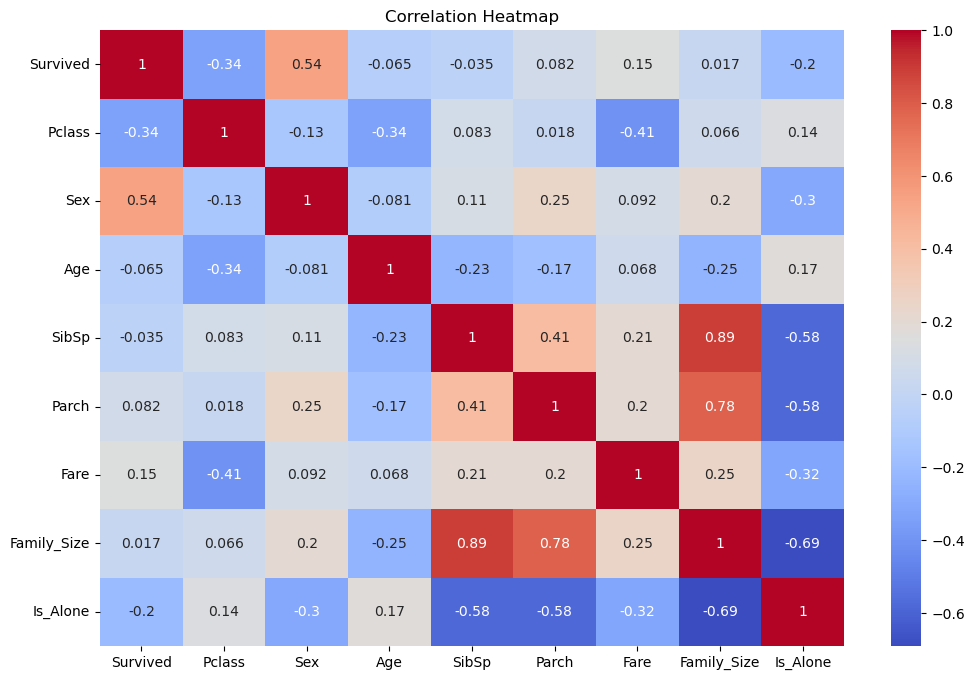

In [69]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')


plt.title('Correlation Heatmap')

plt.show()

In [ ]:
Sex had the strongest relationship with survival.
Passenger class strongly affected outcomes.
Fare-related features positively influenced survival.
Age showed weaker correlation compared to gender and class.

In [ ]:
Strongest Findings

Gender and class together explained most survival outcomes.
Wealth dramatically increased rescue probability.
Third-class adult males were the most vulnerable passengers.
First-class women were the safest group.
Family structure influenced evacuation success.
Fare_Per_Person effectively captured economic comfort.
Combined engineered features improved predictive understanding.

# Final Summary

The analysis of the Titanic Dataset revealed several important patterns related to passenger survival. After performing data cleaning,
feature engineering, encoding, and exploratory data analysis, it became clear that survival on the Titanic was heavily influenced by
social and economic factors.
The dataset showed that female passengers had significantly higher survival rates compared to males. Passenger class also played
a major role, where first-class passengers were much more likely to survive than third-class passengers. Wealthier passengers who
paid higher fares had better access to safety and rescue opportunities.

Age also influenced survival outcomes. Children were more likely to survive, indicating rescue priority for younger passengers. 
Family structure affected survival as well, where passengers traveling in small families had better chances compared to those
traveling alone or in very large families.

Feature engineering further improved the analysis by creating useful variables such as:

Family_Size
Is_Alone
Title
Fare_Per_Person

These features helped uncover hidden behavioral and social patterns within the dataset.

The analysis also demonstrated that the combination of gender, passenger class, and fare created the strongest survival patterns.
Female passengers in first class formed the safest group, while third-class adult males faced the highest mortality.

Overall, the Titanic dataset provided a strong understanding of how economic status, gender, age, and social hierarchy influenced 
survival outcomes during the disaster.



#  Conclusion

The Titanic survival analysis concludes that survival was not random but strongly determined by social and economic conditions.

Passengers with:

female gender,
higher passenger class,
higher ticket fare,
and smaller family groups

had significantly greater survival probabilities.

In contrast:

third-class passengers,
adult males,
low-fare travelers,
and isolated passengers

experienced the highest death rates.

The preprocessing and feature engineering process successfully transformed the raw dataset into a clean and machine-learning-ready
dataset. Important engineered features such as Family_Size, Is_Alone, Title, and Fare_Per_Person enhanced the quality of analysis
and improved predictive understanding.

Overall, the study demonstrates that social hierarchy, wealth, and demographic characteristics played a critical role in determining 
survival during the Titanic disaster.